In [30]:
!pip install tensorflow

In [31]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

(x_train, _), (x_test, _) = mnist.load_data()

# Step 2 — Normalize + Reshape

In [33]:
(train_images, _), (test_images, _) = mnist.load_data()

train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

train_images = train_images[..., np.newaxis]
test_images = test_images[..., np.newaxis]

print("Training Shape :", train_images.shape)
print("Testing Shape :", test_images.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


# Add Noise

In [34]:
noise = 0.30

train_noise = np.random.normal(0, 1, train_images.shape)
test_noise = np.random.normal(0, 1, test_images.shape)

train_noisy = train_images + noise * train_noise
test_noisy = test_images + noise * test_noise

train_noisy = np.clip(train_noisy, 0, 1)
test_noisy = np.clip(test_noisy, 0, 1)

# Build Convolutional Autoencoder

In [35]:
inputs = Input(shape=(28, 28, 1))

# Encoder
encoder = Conv2D(32, 3, activation="relu", padding="same")(inputs)
encoder = MaxPooling2D(pool_size=(2,2), padding="same")(encoder)

encoder = Conv2D(16, 3, activation="relu", padding="same")(encoder)
latent = MaxPooling2D(pool_size=(2,2), padding="same")(encoder)

# Decoder
decoder = Conv2D(16, 3, activation="relu", padding="same")(latent)
decoder = UpSampling2D(size=(2,2))(decoder)

decoder = Conv2D(32, 3, activation="relu", padding="same")(decoder)
decoder = UpSampling2D(size=(2,2))(decoder)

outputs = Conv2D(1, 3, activation="sigmoid", padding="same")(decoder)

model = Model(inputs=inputs, outputs=outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

# Compile Model

In [36]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# Train Model

In [37]:
history = model.fit(
    train_noisy,
    train_images,
    epochs=10,
    batch_size=128,
    validation_data=(test_noisy, test_images),
    shuffle=True,
    verbose=1
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 110ms/step - loss: 0.1547 - val_loss: 0.0966
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - loss: 0.0938 - val_loss: 0.0899
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 120ms/step - loss: 0.0890 - val_loss: 0.0867
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 57s 122ms/step - loss: 0.0865 - val_loss: 0.0846
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - loss: 0.0849 - val_loss: 0.0836
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 118ms/step - loss: 0.0839 - val_loss: 0.0832
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 117ms/step - loss: 0.0832 - val_loss: 0.0822
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 119ms/step - loss: 0.0826 - val_loss: 0.0817
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 56s 120ms/step - loss: 0.0821 - val_loss: 0.0813
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - loss: 0.0817 - val_loss: 0.0812


# Denoise Images

In [38]:
predicted_images = model.predict(test_noisy)

print("Minimum Pixel :", predicted_images.min())
print("Maximum Pixel :", predicted_images.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Minimum Pixel : 1.2295084e-10
Maximum Pixel : 0.9993367


# Display Results

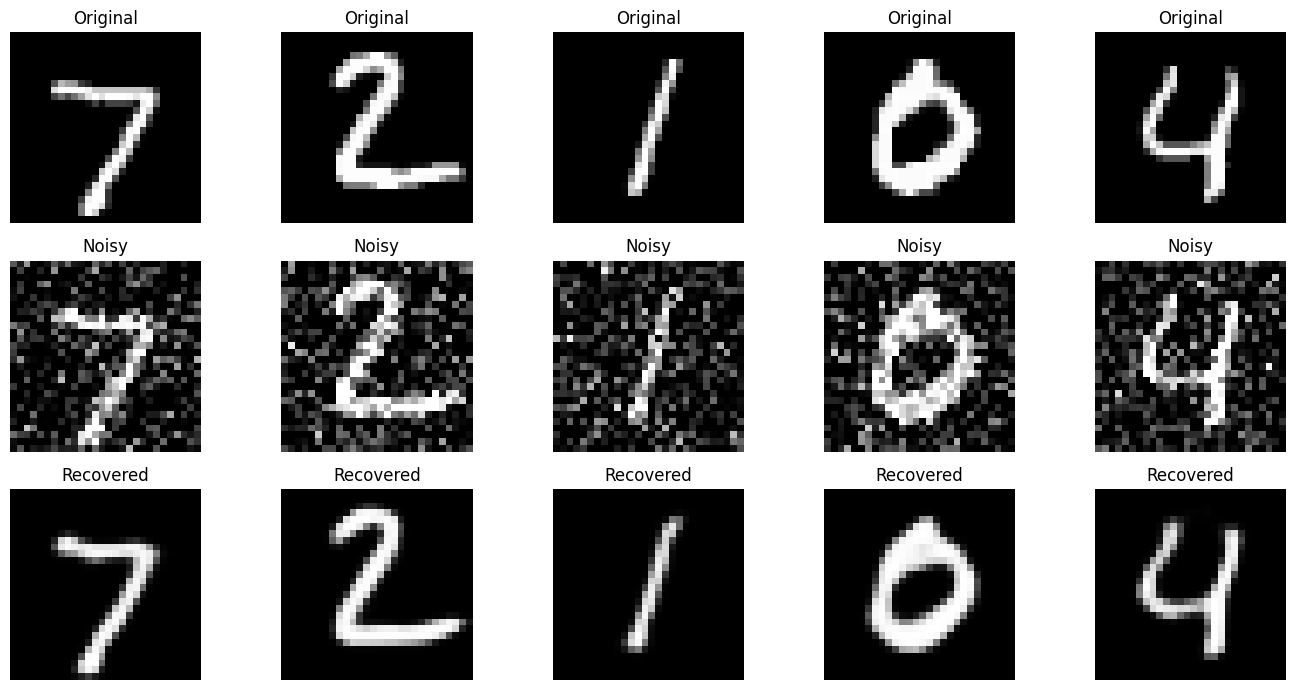

In [39]:
samples = 5

plt.figure(figsize=(14,7))

for i in range(samples):

    # Original
    plt.subplot(3, samples, i+1)
    plt.imshow(test_images[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(3, samples, i+1+samples)
    plt.imshow(test_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed
    plt.subplot(3, samples, i+1+(2*samples))
    plt.imshow(predicted_images[i].squeeze(), cmap="gray")
    plt.title("Recovered")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Plot Loss Graph

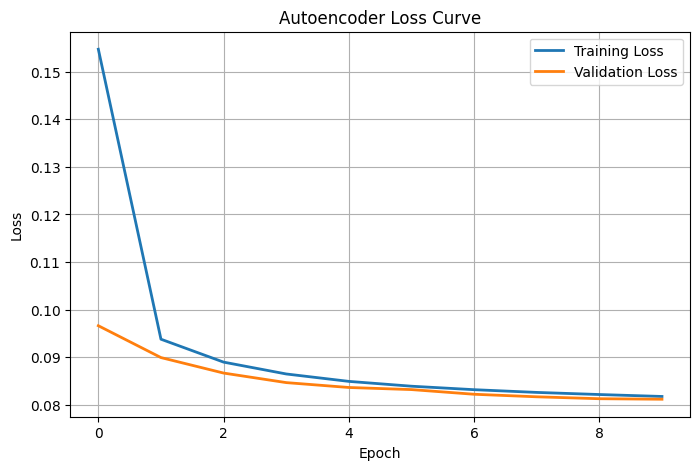

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], linewidth=2, label="Training Loss")
plt.plot(history.history["val_loss"], linewidth=2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Loss Curve")
plt.legend()

plt.grid(True)

plt.show()

# Save the Model

In [41]:
model.save("mnist_denoising_autoencoder.keras")

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

The image denoising project was successfully implemented using a Convolutional Autoencoder on the MNIST handwritten digit dataset. The images were first normalized and artificial Gaussian noise was added to simulate noisy input data. The autoencoder was then trained to learn the mapping between noisy images and their corresponding clean images.

During training, both the training loss and validation loss decreased steadily, indicating that the model learned effectively and generalized well to unseen data. After training, the autoencoder was able to reconstruct clean images from noisy inputs while preserving the important features of the handwritten digits.

The results demonstrate that Convolutional Autoencoders are highly effective for image denoising tasks. This technique can be extended to real-world applications such as medical image enhancement, document restoration, satellite image processing, surveillance image improvement, and image preprocessing for computer vision systems.